In [1]:
#Análisis exploratorio de incidencia delictiva en México
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.read_csv('delitos2.csv')

In [3]:
#Ejercicio 1: Elige 3 estados de la república y grafica una serie de tiempo de la frecuencia absoluta de homicidios dolosos de enero 2015 a julio 2019 en estas tres entidades
#Verificamos las columnas que resultaron de la limpieza de datos en la lección anterior:

for col in df.columns:
    print(col)

anio
clave_ent
entidad
tipo_de_delito
subtipo_de_delito
nombre_mes
fecha
frecuencia


In [7]:
#Definimos la variable datos_long para aplicar los filtros necesarios:
datos_long = df[['anio', 'clave_ent', 'entidad', 'tipo_de_delito', 'subtipo_de_delito', 'nombre_mes', 'fecha', 'frecuencia']]

In [19]:
#Elegimos 3 estados: Ciudad de México, Jalisco y Morelos que corresponden a las entidades 9, 14, y 17 respectivamente, y aplicamos los filtros correspondientes a Homicidio doloso y las fechas.
filtro = datos_long[
    (datos_long.subtipo_de_delito == "Homicidio doloso") &
    (datos_long.clave_ent.isin([9, 14, 17])) &
    (datos_long.fecha >= '2015-01-01') &
    (datos_long.fecha <= '2019-07-01')
]

In [20]:
#Agrupamos por entidad y fecha:
serie = (
    filtro
    .groupby(['entidad', 'fecha'])['frecuencia']
    .sum()
    .reset_index()
)

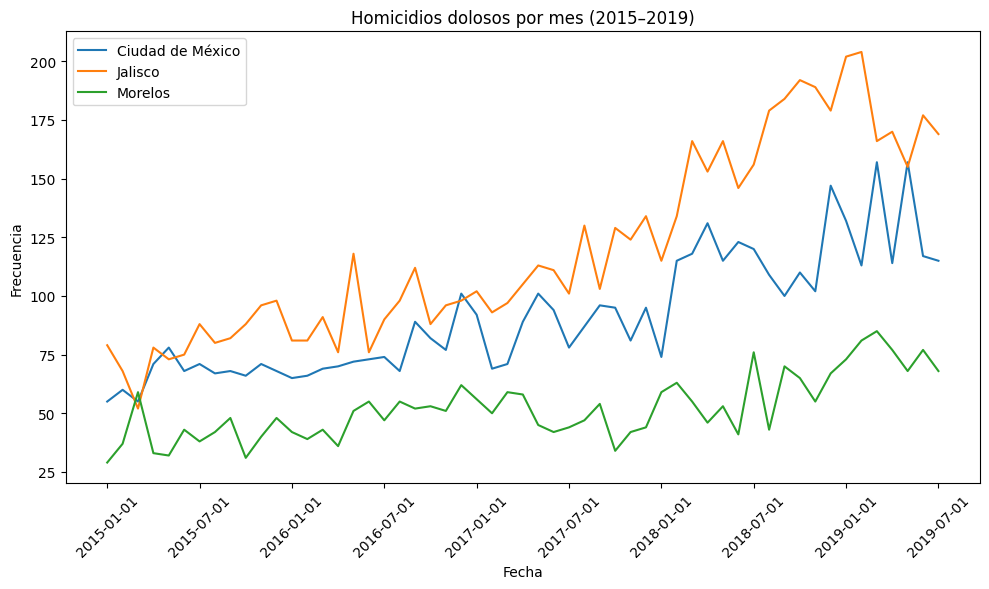

In [21]:
#Generamos la gráfica:
plt.figure(figsize=(10,6))

for entidad in serie['entidad'].unique():
    datos_entidad = serie[serie['entidad'] == entidad]
    plt.plot(datos_entidad['fecha'], datos_entidad['frecuencia'], label=entidad)

plt.xlabel("Fecha")
plt.ylabel("Frecuencia")
plt.title("Homicidios dolosos por mes (2015–2019)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(10))
plt.show()

In [ ]:
#Ejercicio 2: Contesta las siguientes preguntas:

In [24]:
#1.¿Cuántos homicidios dolosos hubo en Colima en el 2018?
#Generamos el filtro:
filtro_colima2018 = datos_long[
    (datos_long.subtipo_de_delito == "Homicidio doloso") &
    (datos_long.clave_ent == 6) &
    (datos_long.anio == 2018)
]

In [30]:
#Agrupamos y sumamos los resultados:
total = (
    filtro_colima2018
    .groupby(['entidad', 'subtipo_de_delito', 'anio'])['frecuencia']
    .sum()
    .reset_index()
)
total

,entidad,subtipo_de_delito,anio,frecuencia
0,Colima,Homicidio doloso,2018,617


In [31]:
#2.¿Cuantos robos de vehículo automotor ha habido en el 2019?
#Aplicamos un nuevo filtro:
filtro_robos_autos = datos_long[
    (datos_long.subtipo_de_delito == "Robo de vehículo automotor") &
    (datos_long.anio == 2019)
]

In [32]:
#Agrupamos y sumamos:
total_robo_auto = (
    filtro_robos_autos
    .groupby(['subtipo_de_delito', 'anio'])['frecuencia']
    .sum()
    .reset_index()
)
total_robo_auto

,subtipo_de_delito,anio,frecuencia
0,Robo de vehículo automotor,2019,187661


In [33]:
#3.Obtén la suma de homicidos dolosos y feminicidios en toda la República Mexicana en cada año.
#Generamos un filtro nuevo:
filtro_homicidios = datos_long[
    (datos_long.subtipo_de_delito.isin (['Homicidio doloso', 'Feminicidio']))
]

In [36]:
#Agrupamos y sumamos manteniendo visibilidad:
tabla_homicidios = (
    filtro_homicidios
    .groupby(['anio', 'subtipo_de_delito'])['frecuencia']
    .sum()
    .unstack()
)
tabla_homicidios['Total'] = tabla_homicidios.sum(axis=1)

tabla_homicidios

subtipo_de_delito,Feminicidio,Homicidio doloso,Total
anio,,,
2015,413,16119,16532
2016,608,20147,20755
2017,745,25032,25777
2018,903,29092,29995
2019,947,29498,30445
2020,947,28839,29786
2021,984,28279,29263
2022,963,26289,27252
2023,832,25308,26140


In [50]:
#¿En qué mes y en qué municipio ha ocurrido el mayor número de feminicidios?
#Es importante notar que nuestra base de datos no contiene información por municipio, así que obtendremos los resultados por estado con un nuevo filtro:
feminicidios = (
    datos_long[
        datos_long.subtipo_de_delito == 'Feminicidio'
    ])

In [52]:
#Agrupamos y ordenamos de mayor a menor frecuencia:
feminicidios_por_estado_por_mes = (
    feminicidios
    .groupby(['entidad', 'nombre_mes', 'anio'])['frecuencia']
    .sum()
    .reset_index()
    .sort_values('frecuencia', ascending=False)
)
feminicidios_por_estado_por_mes

,entidad,nombre_mes,anio,frecuencia
2172,México,julio,2020,19
2129,México,agosto,2021,19
2229,México,octubre,2022,19
2128,México,agosto,2020,17
2196,México,marzo,2022,17
...,...,...,...,...
2081,Morelos,noviembre,2017,0
2068,Morelos,mayo,2015,0
2046,Morelos,junio,2015,0
2042,Morelos,julio,2022,0


In [53]:
#Obtenemos el resultado directo:
feminicidios_por_estado_por_mes.loc[
    feminicidios_por_estado_por_mes['frecuencia'].idxmax()
]

entidad       México
nombre_mes     julio
anio            2020
frecuencia        19
Name: 2172, dtype: object

In [54]:
#¿En qué año y en qué estado ha ocurrido el mayor número de feminicidios?
#Usamos el mismo filtro, pero agrupamos por año:
feminicidios_por_estado_por_anio = (
    feminicidios
    .groupby(['entidad', 'anio'])['frecuencia']
    .sum()
    .reset_index()
    .sort_values('frecuencia', ascending=False)
)
feminicidios_por_estado_por_anio

,entidad,anio,frecuencia
181,México,2020,151
182,México,2021,145
183,México,2022,138
180,México,2019,121
179,México,2018,115
...,...,...,...
25,Baja California Sur,2018,0
132,Hidalgo,2015,0
297,Tamaulipas,2015,0
1,Aguascalientes,2016,0


In [55]:
#Obtenemos el resultado directo:
feminicidios_por_estado_por_anio.loc[
    feminicidios_por_estado_por_anio['frecuencia'].idxmax()
]

entidad       México
anio            2020
frecuencia       151
Name: 181, dtype: object

In [ ]:
#Ejercicio 3: Haz una gráfica de pastel de tipos de delito. 
#Deberás crear una gráfica para cada año. Utiliza la función subplots de matplotlib.

In [56]:
#Generamos una tabla para agrupar nuestros datos:
tabla_tipos_delitos = (
    datos_long
    .groupby(['anio', 'tipo_de_delito'])['frecuencia']
    .sum()
    .reset_index()
)

In [58]:
#Separamos los datos por años:
anios = sorted(tabla_tipos_delitos['anio'].unique())

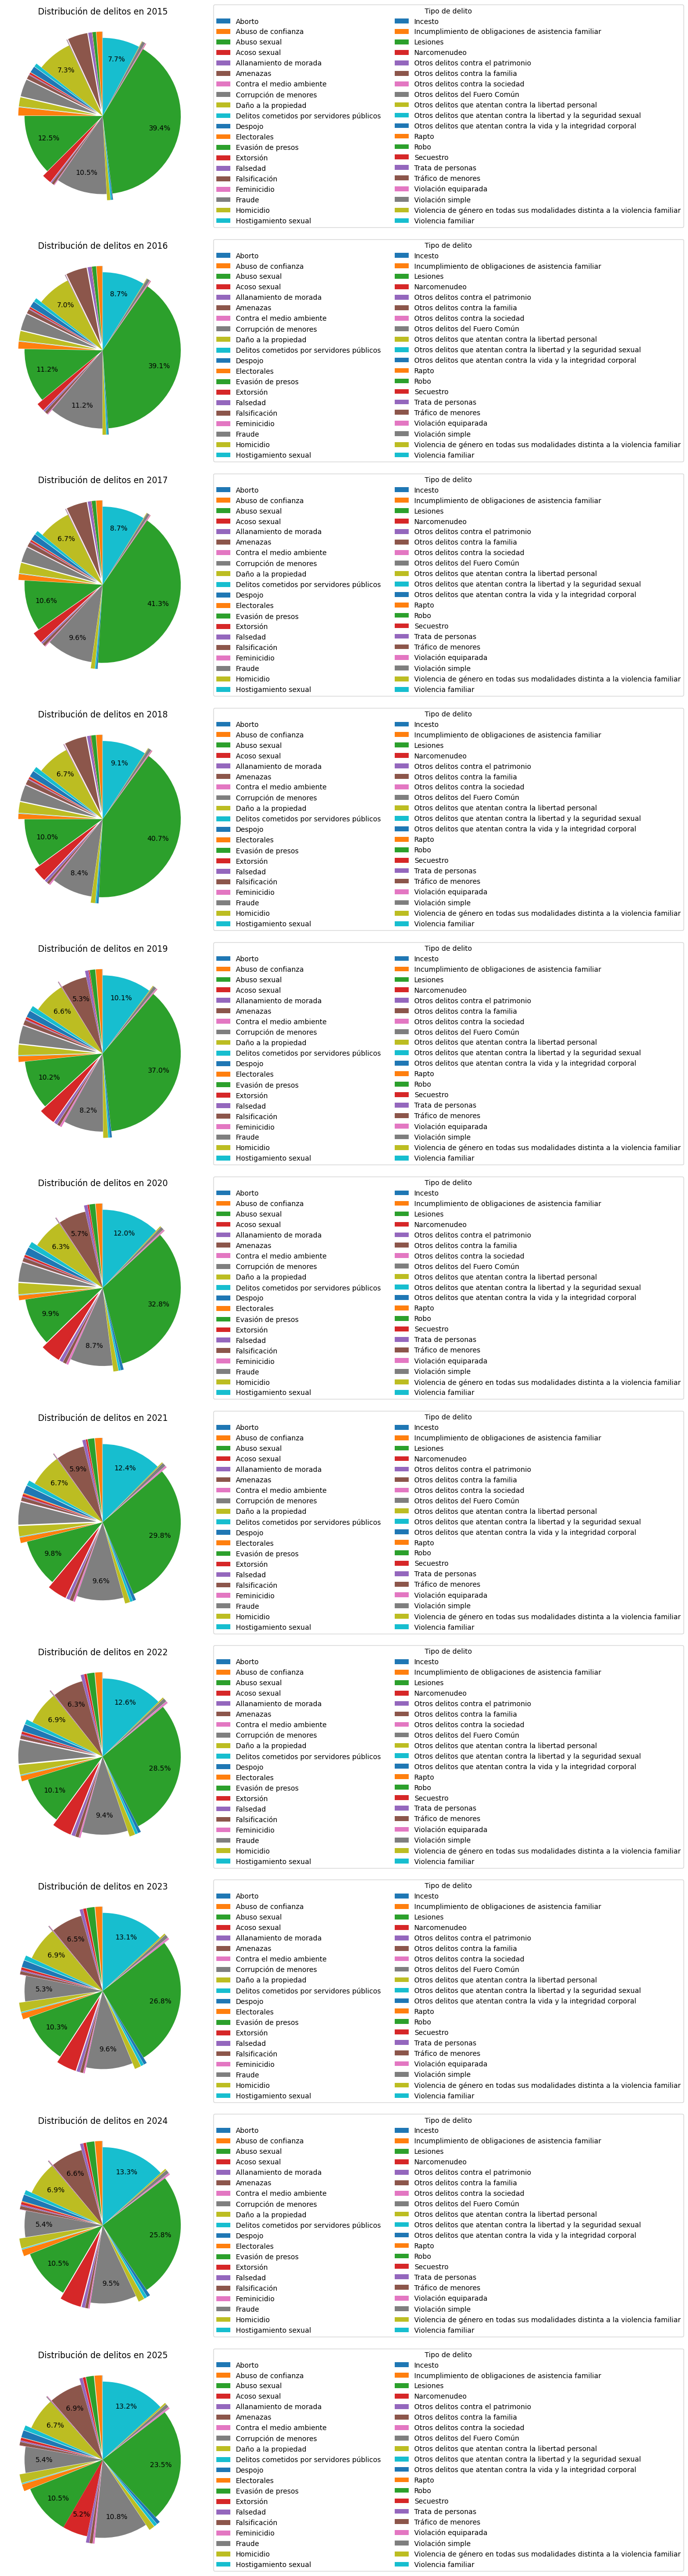

In [77]:
#Creamos una función para controlas cuáles datos se muestran en el gráfico:
def formato_porcentaje(pct):
    return f'{pct:.1f}%' if pct >= 5 else ''

#Creamos subplots:
fig, axes = plt.subplots(
    nrows = len(anios),
    ncols = 1,
    figsize = (14, 6 * len(anios))
)

if len(anios) == 1:
    axes = [axes]

for ax, anio in zip(axes, anios):
    datos_anio = tabla_tipos_delitos[tabla_tipos_delitos['anio'] == anio]

#Modificamos la visualización de los porcentajes en las gráficas para hacerlos legibles:     
    explode = [
    0.08 if (freq / datos_anio['frecuencia'].sum()) < 0.05 else 0
    for freq in datos_anio['frecuencia']
]
    wedges, texts, autotexts = ax.pie(
    datos_anio['frecuencia'],
    autopct=formato_porcentaje,
    startangle=90,
    pctdistance=0.75,
    explode=explode  
) 
    ax.set_title(f"Distribución de delitos en {anio}")

#Agregamos las leyendas a un costado:
    ax.legend(
        wedges,
        datos_anio['tipo_de_delito'],
        title = "Tipo de delito",
        loc = "center left",
        bbox_to_anchor = (1.05, 0.5),
        ncol = 2
    )

plt.subplots_adjust(right = 0.75)
plt.show()

In [80]:
#Ejercicio 4: Calcula la tasa de incidencia delictiva por 100,000 habitantes

In [81]:
#Recuperamos los datos de la población por entidad federativa:
pobs = pd.read_csv('poblacion_entidades_2015.csv', encoding='iso-8859-1', sep=";")
pobs = pobs[['Cve_Entidad', 'Entidad', 'Poblacion']]
pobs = pobs.rename(columns={'Cve_Entidad':'clave_entidad', 'Entidad':'entidad', 'Poblacion':'poblacion'})
pobs

,clave_entidad,entidad,poblacion
0,1,Aguascalientes,1312544.0
1,2,Baja California,3315766.0
2,3,Baja California Sur,712029.0
3,4,Campeche,899931.0
4,5,Coahuila de Zaragoza,5217908.0
5,6,Colima,3556574.0
6,7,Chiapas,8918653.0
7,8,Chihuahua,2954915.0
8,9,Ciudad de México,711235.0
9,10,Durango,1754754.0


In [84]:
#Creamos un filtro para recuperar los delitos totales por entidad poara 2015, pues es el año del censo anterior:
delitos_2015 = datos_long[
    (datos_long.anio == 2015)
]

In [86]:
#Agrupamos por entidad:
delitos_entidad = (
    delitos_2015
    .groupby (['clave_ent', 'entidad'])['frecuencia']
    .sum()
    .reset_index()
)
delitos_entidad

,clave_ent,entidad,frecuencia
0,1,Aguascalientes,23212
1,2,Baja California,119944
2,3,Baja California Sur,21415
3,4,Campeche,1886
4,5,Coahuila de Zaragoza,46569
5,6,Colima,6562
6,7,Chiapas,21618
7,8,Chihuahua,61280
8,9,Ciudad de México,169701
9,10,Durango,29088


In [92]:
#Unimos la base de datos de delitos con la de población por clave:
delitos_pob_2015 = delitos_entidad.merge(
    pobs,
    left_on='clave_ent',
    right_on='clave_entidad',
    how='left'
)

In [95]:
#Calculamos tasa por cada 100 mil habitantes:
delitos_pob_2015['tasa_100k'] = (
    delitos_pob_2015['frecuencia'] /
    delitos_pob_2015['poblacion']
) * 100000

#Dado que el filtro inicial ya es una sumatoria de los delitos registrados en todo el año 2015, no es necesario 'anualizar' este resultado.

In [96]:
tasa_incidencia_delictiva = (
    delitos_pob_2015[['entidad_x', 'frecuencia', 'poblacion', 'tasa_100k']]
    .sort_values('tasa_100k', ascending=False)
)

tasa_incidencia_delictiva

,entidad_x,frecuencia,poblacion,tasa_100k
8,Ciudad de México,169701,711235.0,23860.046258
1,Baja California,119944,3315766.0,3617.384339
2,Baja California Sur,21415,712029.0,3007.602218
16,Morelos,49245,1903811.0,2586.653822
26,Tabasco,57452,2395272.0,2398.558494
22,Quintana Roo,32496,1501562.0,2164.146402
7,Chihuahua,61280,2954915.0,2073.832919
14,México,323525,16187608.0,1998.596704
0,Aguascalientes,23212,1312544.0,1768.474047
9,Durango,29088,1754754.0,1657.668254
